In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [3]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv"
)

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
df.shape

(167, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [7]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

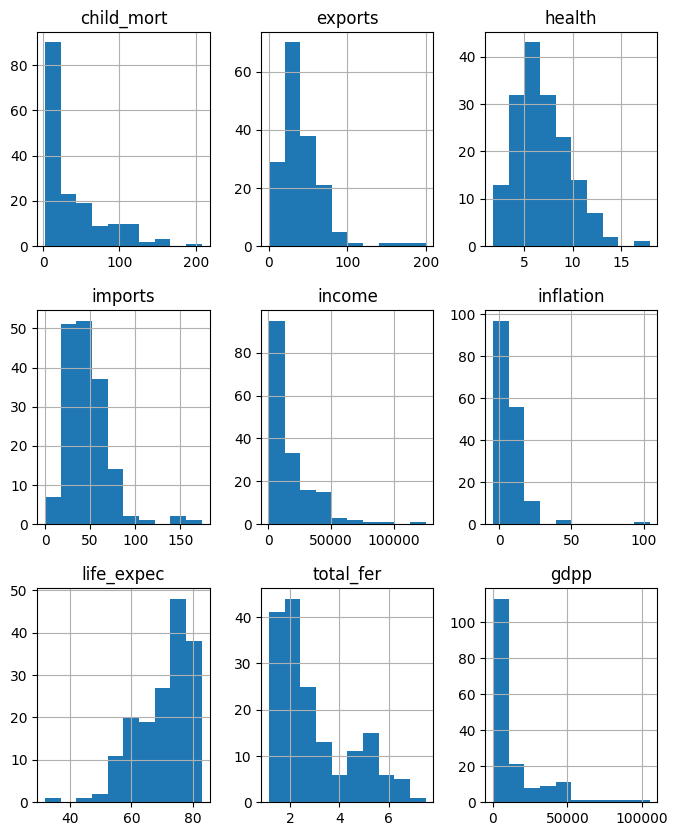

In [9]:
df.hist(figsize=(8,10))
plt.show()

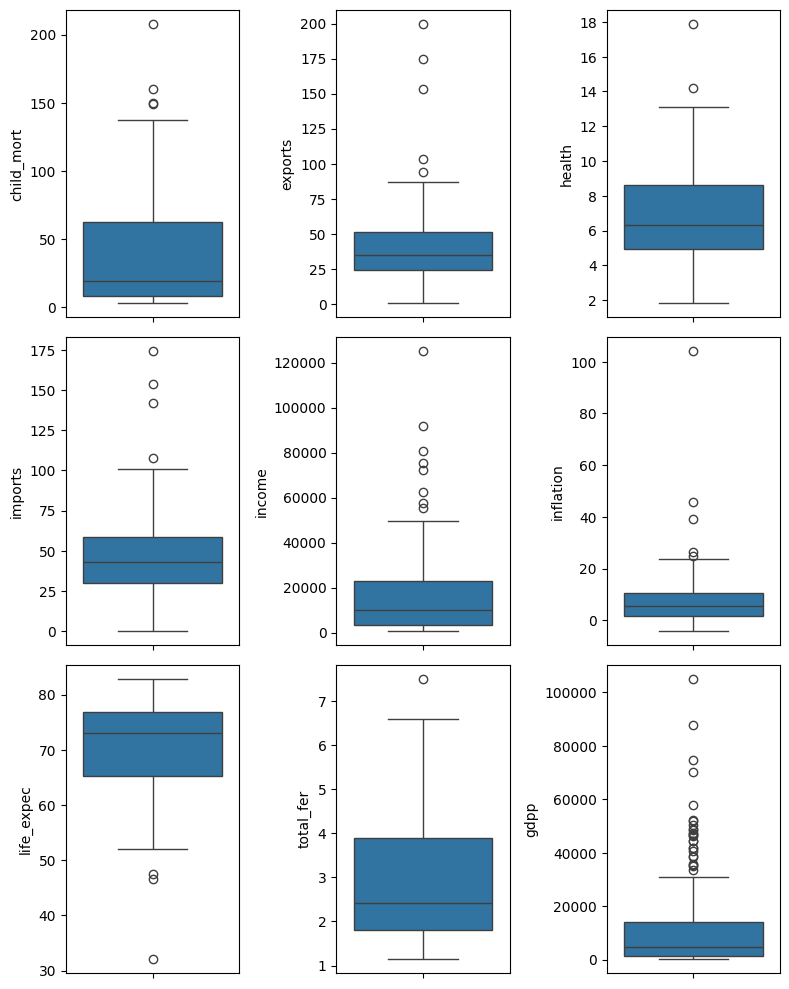

In [10]:
plt.figure(figsize=(8, 10))

for i,col in enumerate(df.columns[1:]):
    plt.subplot(3,3, i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

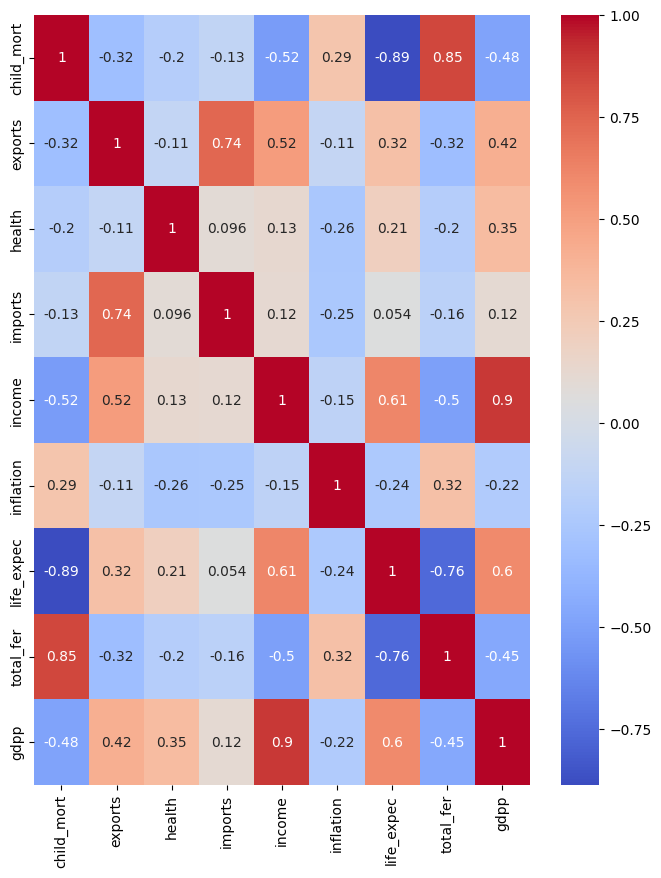

In [11]:
plt.figure(figsize=(8,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.show()

In [12]:
country_names = df["country"]

x = df.drop("country", axis=1)

In [13]:
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [14]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(x_scaled)

    wcss.append(kmeans.inertia_)

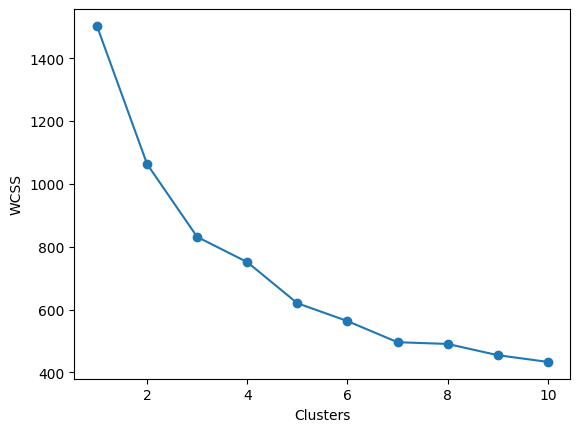

In [15]:
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [16]:
for k in range(2,8):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(x_scaled)

    score = silhouette_score(
        x_scaled,
        labels
    )

    print(k,score)

2 0.2662961111870726
3 0.285600988953231
4 0.2880471307804802
5 0.30088229124112015
6 0.23565028812238528
7 0.2479313491087983


In [17]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df["Clusters"] = kmeans.fit_predict(x_scaled)

In [18]:
df["Clusters"].value_counts()

Clusters
0    86
2    45
1    36
Name: count, dtype: int64

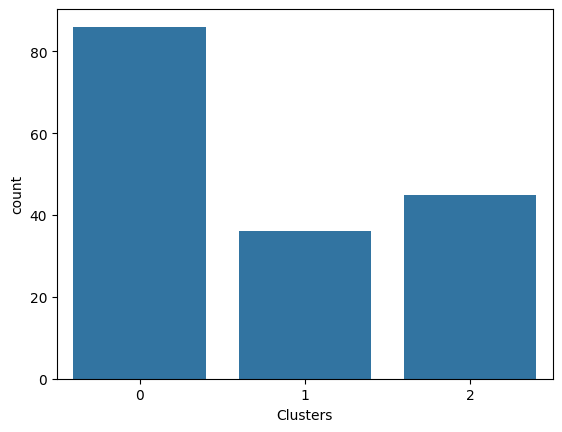

In [19]:
sns.countplot(x="Clusters",data=df)
plt.show()

In [20]:
cluster_summary = df.groupby("Clusters").mean(
    numeric_only=True
)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Clusters,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


In [21]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(x_scaled)

In [22]:
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"]
)

pca_df["Clusters"] = df["Clusters"]

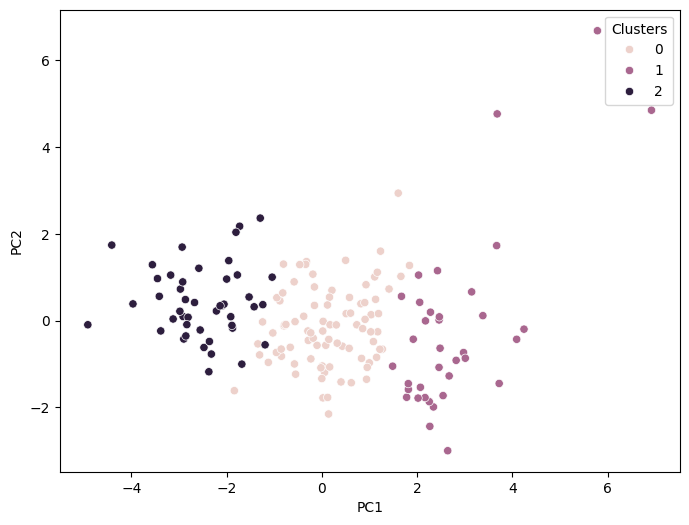

In [23]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Clusters",
    data=pca_df
)

plt.show()

In [24]:
print(
    sum(pca.explained_variance_ratio_)
)

0.6313336543771411


In [25]:
needy_cluster = 2

df[df["Clusters"] == needy_cluster][
["country", "income", "gdpp", "child_mort"]
]

,country,income,gdpp,child_mort
0,Afghanistan,1610,553,90.2
3,Angola,5900,3530,119.0
17,Benin,1820,758,111.0
25,Burkina Faso,1430,575,116.0
26,Burundi,764,231,93.6
28,Cameroon,2660,1310,108.0
31,Central African Republic,888,446,149.0
32,Chad,1930,897,150.0
36,Comoros,1410,769,88.2
37,"Congo, Dem. Rep.",609,334,116.0


In [26]:
df[df["Clusters"] == needy_cluster].sort_values(
    by="gdpp"
)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Clusters
26,Burundi,93.6,8.92,11.60,39.2,764,12.300,57.7,6.26,231,2
88,Liberia,89.3,19.10,11.80,92.6,700,5.470,60.8,5.02,327,2
37,"Congo, Dem. Rep.",116.0,41.10,7.91,49.6,609,20.800,57.5,6.54,334,2
112,Niger,123.0,22.20,5.16,49.1,814,2.550,58.8,7.49,348,2
132,Sierra Leone,160.0,16.80,13.10,34.5,1220,17.200,55.0,5.20,399,2
93,Madagascar,62.2,25.00,3.77,43.0,1390,8.790,60.8,4.60,413,2
106,Mozambique,101.0,31.50,5.21,46.2,918,7.640,54.5,5.56,419,2
31,Central African Republic,149.0,11.80,3.98,26.5,888,2.010,47.5,5.21,446,2
94,Malawi,90.5,22.80,6.59,34.9,1030,12.100,53.1,5.31,459,2
50,Eritrea,55.2,4.79,2.66,23.3,1420,11.600,61.7,4.61,482,2


In [27]:
top10 = (
df[df["Clusters"]==needy_cluster]
.sort_values(by="gdpp")
.head(10)
)

top10

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Clusters
26,Burundi,93.6,8.92,11.60,39.2,764,12.30,57.7,6.26,231,2
88,Liberia,89.3,19.10,11.80,92.6,700,5.47,60.8,5.02,327,2
37,"Congo, Dem. Rep.",116.0,41.10,7.91,49.6,609,20.80,57.5,6.54,334,2
112,Niger,123.0,22.20,5.16,49.1,814,2.55,58.8,7.49,348,2
132,Sierra Leone,160.0,16.80,13.10,34.5,1220,17.20,55.0,5.20,399,2
93,Madagascar,62.2,25.00,3.77,43.0,1390,8.79,60.8,4.60,413,2
106,Mozambique,101.0,31.50,5.21,46.2,918,7.64,54.5,5.56,419,2
31,Central African Republic,149.0,11.80,3.98,26.5,888,2.01,47.5,5.21,446,2
94,Malawi,90.5,22.80,6.59,34.9,1030,12.10,53.1,5.31,459,2
50,Eritrea,55.2,4.79,2.66,23.3,1420,11.60,61.7,4.61,482,2
